# E-commerce Abnormal Order Detection with an Ensemble Model — Business Background and Data Exploration (Part 1)

---

## Project Background

In e-commerce, **abnormal order detection** is essential for transaction security and a healthy marketplace. Abnormal orders may involve fabricated transactions, malicious ordering, promotion abuse, fraud, and other behaviors that harm the platform and its merchants while degrading the experience of legitimate customers.

This project aims to build an ensemble-learning solution for detecting abnormal e-commerce orders. Before modeling, **exploratory data analysis (EDA)** is indispensable: understanding the data's structure, quality, and business meaning provides the foundation for sound feature engineering and model development.

### Objectives of Part 1

1. **Understand the data source and business context:** infer the platform and business scenario by examining each feature.
2. **Assess data quality:** identify missing values, duplicates, and numerical outliers.
3. **Preprocess the data:** clean the dataset based on the exploratory findings so it is ready for modeling.
4. **Discover business patterns:** uncover insights associated with abnormal transactions.

## 1. Data Loading and Initial Understanding

This section loads the dataset and examines every feature to establish an initial understanding of both the data and the business. In anomaly-detection projects, the business meaning of each feature is especially important because the definition of an anomaly depends heavily on its operational context.

### 1.1 Import the Required Libraries

Import the core libraries used for data analysis and visualization:

- **pandas:** data loading, manipulation, and analysis
- **NumPy:** numerical computing
- **Matplotlib:** data visualization
- **Seaborn:** statistical visualization

The plotting theme is also configured for consistent English-language charts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["axes.unicode_minus"] = False

### 1.2 Load the Dataset

Use `pd.read_csv()` to load the abnormal-order dataset from the local `data` directory.

In [2]:
data = pd.read_csv(r"data/abnormal_orders.txt")

### 1.3 Dataset Overview

#### Preview the First Five Rows

Use `data.head()` to inspect the column names, formats, and representative values.

In [3]:
data.head() # Preview the dataset.

,order_id,order_date,order_time,cat,attribution,pro_id,pro_brand,total_money,total_quantity,order_source,pay_type,user_id,city,abnormal_label
0,4277880103,2013-10-17,13:09:16,NaN,GO,8000001215,NaN,1000.0,1000,游戏站点,当当支付,murongchun,北京市,0
1,4283851335,2013-09-23,14:09:49,手机摄影数码,POP,8002042497,三星,766000.0,200,主站,合并支付,dakehu_zy,上海市,1
2,4277700101,2013-08-27,14:26:38,NaN,GO,7000000960,国之美艺术品,8000.0,160,do.site_id,在线支付,1391175862,NaN,1
3,4276537082,2013-09-11,14:16:47,电视冰箱洗衣机空调,POP,8001992420,樱花,19900.0,100,主站,合并支付,qq-3be293b,泉州市,1
4,4281111595,2013-04-10,10:44:46,家具建材,POP,8002199518,纬度空间,100.0,100,主站,合并支付,nonscorpio,广州市,1


**Interpretation:**

The dataset contains 14 fields, and each row represents one transaction record. The initial interpretation of the fields is:

| Original field | Inferred meaning | Type |
|---|---|---|
| order_id | Order identifier | Identifier |
| order_date | Order date | Date |
| order_time | Order time | Time |
| cat | Top-level product category | Categorical |
| attribution | Product source/channel | Categorical |
| pro_id | Product identifier | Identifier |
| pro_brand | Brand | Categorical |
| total_money | Order amount | Continuous |
| total_quantity | Quantity sold | Discrete |
| order_source | Order channel | Categorical |
| pay_type | Payment method | Categorical |
| user_id | Customer identifier | Identifier |
| city | Delivery city | Categorical |
| abnormal_label | Abnormality label (0 = normal, 1 = abnormal) | Target |

Several fields contain missing values, including `cat`, `pro_brand`, and `city`; these will be investigated later.

#### Inspect the Column Names

Use `data.columns` to retrieve all column names for subsequent column-level operations.

In [4]:
data.columns

Index(['order_id', 'order_date', 'order_time', 'cat', 'attribution', 'pro_id',
       'pro_brand', 'total_money', 'total_quantity', 'order_source',
       'pay_type', 'user_id', 'city', 'abnormal_label'],
      dtype='object')

**Interpretation:** The dataset has 14 compact field names. They will be replaced with clearer English names for readability.

#### Inspect the Number of Rows and Columns

`data.shape` returns `(rows, columns)`, or equivalently `(number of observations, number of fields)`.

In [5]:
data.shape

(134190, 14)

**Interpretation:** The dataset contains **134,190 records** and **14 fields**, making it a medium-sized dataset. The fields comprise one target and 13 candidate features.

### 1.4 Rename the Features

Replace the compact source-system names with descriptive English column names.

In [6]:
data.columns = [
    "Order ID", "Order Date", "Order Time", "Product Category",
    "Product Attribution", "Product ID", "Brand", "Order Amount",
    "Quantity", "Order Channel", "Payment Method", "User ID",
    "City", "Abnormal Label"
]

In [7]:
data.columns.tolist()

['Order ID',
 'Order Date',
 'Order Time',
 'Product Category',
 'Product Attribution',
 'Product ID',
 'Brand',
 'Order Amount',
 'Quantity',
 'Order Channel',
 'Payment Method',
 'User ID',
 'City',
 'Abnormal Label']

In [8]:
data.head(5)

,Order ID,Order Date,Order Time,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,User ID,City,Abnormal Label
0,4277880103,2013-10-17,13:09:16,NaN,GO,8000001215,NaN,1000.0,1000,游戏站点,当当支付,murongchun,北京市,0
1,4283851335,2013-09-23,14:09:49,手机摄影数码,POP,8002042497,三星,766000.0,200,主站,合并支付,dakehu_zy,上海市,1
2,4277700101,2013-08-27,14:26:38,NaN,GO,7000000960,国之美艺术品,8000.0,160,do.site_id,在线支付,1391175862,NaN,1
3,4276537082,2013-09-11,14:16:47,电视冰箱洗衣机空调,POP,8001992420,樱花,19900.0,100,主站,合并支付,qq-3be293b,泉州市,1
4,4281111595,2013-04-10,10:44:46,家具建材,POP,8002199518,纬度空间,100.0,100,主站,合并支付,nonscorpio,广州市,1


**Interpretation:** The columns have been renamed successfully; the underlying data is unchanged.

### 1.5 Target Exploration: Abnormal-Label Distribution

Understanding the class distribution is critical in classification. If the classes are severely imbalanced, later modeling may require oversampling (for example, SMOTE), undersampling, or class-weight adjustment.

In [9]:
(data["Abnormal Label"] == 1).sum()

np.int64(28457)

In [10]:
(data["Abnormal Label"] == 1).sum()/data.shape[0] # The class imbalance is mild.

np.float64(0.2120649824875177)

**Interpretation:**

- There are **28,457 abnormal records**, approximately **21.2%** of the dataset.
- The normal-to-abnormal ratio is about 4:1, which is only mild imbalance; ratios above 10:1 are more commonly considered severe.
- Although the target identifies abnormal transactions, its precise business definition is not documented and must be inferred through further exploration.

### 1.6 Time-Feature Exploration: Order Date

Time features are important in e-commerce. The distribution of order dates is examined below.

In [11]:
data["Order Date"].value_counts()

Order Date
2013-10-31    690
2013-03-21    429
2013-11-01    426
2013-01-24    422
2013-03-23    416
             ... 
2013-07-31     17
2013-08-31     14
2013-01-31      2
2013-03-31      2
2013-05-31      2
Name: count, Length: 364, dtype: int64

**Interpretation:**

- There are **364 unique dates**, covering 364 of the 365 days in 2013.
- Daily volume ranges from 2 to 690 transactions.
- Only two transactions per day would be implausible for a large e-commerce platform, indicating that this is a **sample of the year's transactions**, not the complete population.

### 1.7 Order-ID Exploration: Uniqueness Check

Order identifiers are usually unique at the order level. Checking duplication helps determine whether the dataset is recorded at the order level or at a finer transaction-line level.

In [12]:
# Check whether Order ID is unique.
data["Order ID"].duplicated().sum()

np.int64(19212)

**Interpretation:**

The Order ID field contains **19,212 duplicated occurrences**. This suggests that:

> - Some observations may be true duplicate records that should be removed.
> - Each row may instead represent a product or transaction line within an order, so the target may describe transaction-line abnormality rather than an entire order.

The second explanation appears likely and will be tested during duplicate analysis.

### 1.8 Product-Category Exploration

The top-level product category provides evidence about the platform's product range and core business.

In [13]:
data["Product Category"].value_counts()

Product Category
手机摄影数码       20612
生活电器厨卫电器     19281
家纺寝居         18679
电脑办公打印文仪     11405
家居日用         10642
电视冰箱洗衣机空调     9067
美妆个护          9043
汽车用品          6490
家具建材          4941
食品酒水          4669
健康医疗          4252
服饰鞋帽          4067
运动户外          3934
母婴用品玩具        2664
箱包奢品          1962
钟表首饰           860
图书音像           232
Name: count, dtype: int64

In [14]:
# The leading categories are electronics, small appliances, and home textiles,
# suggesting an e-commerce retailer with a strong home-appliance focus.

**Interpretation:** There are **17 top-level categories**. The three largest are mobile phones/photography/digital products, household and kitchen appliances, and home textiles/bedding. The assortment is dominated by electronics and home appliances, suggesting a broad appliance-oriented retailer.

### 1.9 Channel Exploration

#### Product Attribution

This field represents the product-fulfillment model: direct retail versus third-party marketplace sellers.

In [15]:
data["Product Attribution"].value_counts()

Product Attribution
GO     91170
POP    43020
Name: count, dtype: int64

In [16]:
(data["Product Attribution"] == "GO").sum()/data.shape[0]

np.float64(0.6794097920858484)

**Interpretation:**

- The **GO channel** accounts for approximately **67.9%** (91,170 records), while **POP** accounts for about 32.1% (43,020 records).
- **POP** means Platform Open Plan, in which third-party or individual merchants sell through the platform.
- The meaning of **GO** is not yet certain and will be inferred from additional evidence.

#### Order Channel

This field describes the source or traffic entry point through which the transaction occurred.

In [17]:
data["Order Channel"].value_counts()

Order Channel
主站            96894
抢购            16256
手机站点           7098
团购             6294
手机抢购           3095
do.site_id     2394
手机团购           1074
充值              703
当当              377
游戏站点              5
Name: count, dtype: int64

**Interpretation:**

- **Main site** (96,894): the dominant channel, representing the desktop website.
- **Flash sale** (16,256): limited-time promotional purchases.
- **Mobile site / mobile flash sale / mobile group buying:** mobile channels.
- **do.site_id** (2,394): external campaign media identifiers, such as SMS, SEO, or desktop pop-ups.
- **Top-up** (703): mobile credit, QQ membership, or game-credit top-ups.
- **Dangdang** (377): transactions through the Dangdang channel.

**Key inference:** The presence of Dangdang and top-up channels provides important clues:

1. Dangdang began as a bookseller and was not known primarily for appliances.
2. GOME and Dangdang announced a partnership in 2012, with GOME opening a storefront on Dangdang.
3. As an appliance and electronics retailer, GOME naturally supported mobile top-up services.

Taken together, the evidence suggests that **this dataset is a sample of GOME's online transactions from 2013**. The previously ambiguous abbreviation **GO** most likely refers to **GOME**.

### 1.10 Payment-Method Exploration

Payment methods reveal customer payment preferences and the platform's payment capabilities.

In [18]:
data["Payment Method"].value_counts()

Payment Method
合并支付    104274
货到付款     26785
当当支付      2511
在线支付       421
账户余额       199
Name: count, dtype: int64

**Interpretation:**

- **Combined payment** (104,274): shopping-cart payment and the dominant method.
- **Cash on delivery** (26,785): common for direct-retail platforms.
- **Dangdang payment** (2,511): further evidence of the connection to Dangdang.
- **Online payment** (421) and **account balance** (199): only small shares of the data.

### 1.11 City Exploration

The city feature helps describe the geographic distribution of the platform's customers.

In [19]:
data["City"].value_counts()

City
北京市        14554
上海市         6637
广州市         6033
深圳市         5468
天津市         3393
           ...  
果洛州            1
昌都地区           1
四川省其他城市        1
江西省其他城市        1
神农架林区          1
Name: count, Length: 365, dtype: int64

**Interpretation:** The dataset covers **365 cities**. Beijing, Shanghai, Guangzhou, and Shenzhen have the largest counts, consistent with stronger e-commerce consumption in China's largest cities. City is a high-cardinality categorical feature and will require an appropriate encoding strategy during feature engineering.

### 1.12 Data Types and Memory Usage

Use `data.info()` to inspect the overall structure of the dataset.

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134190 entries, 0 to 134189
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Order ID             134190 non-null  int64  
 1   Order Date           134190 non-null  object 
 2   Order Time           134190 non-null  object 
 3   Product Category     132800 non-null  object 
 4   Product Attribution  134190 non-null  object 
 5   Product ID           134190 non-null  int64  
 6   Brand                133418 non-null  object 
 7   Order Amount         134189 non-null  float64
 8   Quantity             134190 non-null  int64  
 9   Order Channel        134190 non-null  object 
 10  Payment Method       134190 non-null  object 
 11  User ID              134190 non-null  object 
 12  City                 134188 non-null  object 
 13  Abnormal Label       134190 non-null  int64  
dtypes: float64(1), int64(4), object(9)
memory usage: 14.3+ MB


**Interpretation:**

- **Dataset size:** 134,190 records and over 14.3 MB, which is manageable on a typical computer.
- **Missing values:** Product Category (1,390), Brand (772), Order Amount (1), and City (2).
- **Data types:** one `float64`, four `int64`, and nine `object` fields. Nearly all usable predictors are currently stored as objects.

### 1.13 Integer-Feature Analysis

Inspect the integer-valued fields and assess their suitability for modeling.

In [21]:
data.select_dtypes(include="int64").head()

,Order ID,Product ID,Quantity,Abnormal Label
0,4277880103,8000001215,1000,0
1,4283851335,8002042497,200,1
2,4277700101,7000000960,160,1
3,4276537082,8001992420,100,1
4,4281111595,8002199518,100,1


**Interpretation:** Of the four integer fields, Abnormal Label is the target; Order ID and Product ID are discrete identifiers that should not be used directly as numerical predictors; only **Quantity** is suitable as a quantitative feature. Therefore, the only two directly usable continuous or quantitative features are **Order Amount** and **Quantity**.

---

## 2. Missing-Value Analysis and Treatment

An important question in anomaly detection is whether **missingness itself is associated with abnormal transactions**. If it is, a missing-value indicator may be a useful feature.

### 2.1 Missing-Value Overview

In [22]:
data.isnull().sum()

Order ID                  0
Order Date                0
Order Time                0
Product Category       1390
Product Attribution       0
Product ID                0
Brand                   772
Order Amount              1
Quantity                  0
Order Channel             0
Payment Method            0
User ID                   0
City                      2
Abnormal Label            0
dtype: int64

**Interpretation:** Four features contain missing values: Product Category (1,390), Brand (772), Order Amount (1), and City (2). Missingness in Order Amount and City is negligible.

### 2.2 Missing-Value Percentages

In [23]:
data.isnull().sum()*100/data.shape[0]

Order ID               0.000000
Order Date             0.000000
Order Time             0.000000
Product Category       1.035845
Product Attribution    0.000000
Product ID             0.000000
Brand                  0.575304
Order Amount           0.000745
Quantity               0.000000
Order Channel          0.000000
Payment Method         0.000000
User ID                0.000000
City                   0.001490
Abnormal Label         0.000000
dtype: float64

**Interpretation:** Product Category is 1.04% missing and Brand is 0.58% missing; both percentages are very small.

### 2.3 Relationship Between Missingness and the Target

Use a Venn-diagram-style illustration to reason about the overlap between records with missing values and abnormal records.

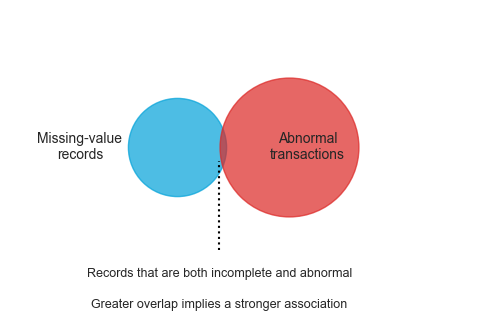

In [24]:
plt.figure(figsize=(6, 4), dpi=100)
plt.scatter(2.8, 5, s=5000, c="#01a2d9", alpha=0.7, label="Records with missing values")
plt.scatter(4, 5, s=10000, c="#dc2624", alpha=0.7, label="Abnormal transactions")
plt.xlim(1, 6)
plt.ylim(2.5, 7)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

plt.text(1.75, 5, s="Missing-value\nrecords", fontsize=10, ha="center", va="center")
plt.text(4.2, 5, s="Abnormal\ntransactions", fontsize=10, ha="center", va="center")
plt.vlines(3.25, 3.5, 4.8, colors="black", linestyles="dotted")
plt.text(3.25, 3.1, s="Records that are both incomplete and abnormal", fontsize=9, ha="center")
plt.text(3.25, 2.65, s="Greater overlap implies a stronger association", fontsize=9, ha="center")
plt.xticks([])
plt.yticks([])
plt.show()

**Perspective 1:** Evaluate `intersection / all records with missing values`. A high percentage would indicate a strong association between missingness and abnormality.

In [25]:
for column in ["Product Category", "Brand"]:
    abnormal_share = (
        100 * data.loc[data[column].isnull(), "Abnormal Label"].sum()
        / data[column].isnull().sum()
    )
    print(f"Abnormal share among records missing {column}: {abnormal_share:.3f}%")

Abnormal share among records missing Product Category: 11.727%
Abnormal share among records missing Brand: 20.984%


**Interpretation:** Only 11.7% of records missing Product Category are abnormal, while approximately 21.0% of records missing Brand are abnormal. Given the overall abnormal rate of about 21.2%, **missingness has little association with transaction abnormality**.

**Perspective 2:** Evaluate `intersection / all abnormal records`—the share of abnormal records that also contain a missing value. A high percentage would mean that deleting incomplete records could discard a substantial part of the abnormal class.

In [26]:
for column in ["Product Category", "Brand"]:
    missing_share = (
        100 * data.loc[data[column].isnull(), "Abnormal Label"].sum()
        / (data["Abnormal Label"] == 1).sum()
    )
    print(f"Share of all abnormal records that are missing {column}: {missing_share:.3f}%")

Share of all abnormal records that are missing Product Category: 0.573%
Share of all abnormal records that are missing Brand: 0.569%


**Interpretation:** Records with missing values account for less than 0.6% of all abnormal records. This percentage is **very small**, so deletion is safe.

### 2.4 Missing-Value Treatment

The analysis shows that missingness is not associated with the target and affects only a small share of the data. **All rows containing a missing value are therefore removed.**

In [27]:
data.dropna(how="any",inplace=True)

### 2.5 Validate the Cleaned Data

In [28]:
data.info() # No missing values remain.

<class 'pandas.core.frame.DataFrame'>
Index: 132761 entries, 1 to 134189
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Order ID             132761 non-null  int64  
 1   Order Date           132761 non-null  object 
 2   Order Time           132761 non-null  object 
 3   Product Category     132761 non-null  object 
 4   Product Attribution  132761 non-null  object 
 5   Product ID           132761 non-null  int64  
 6   Brand                132761 non-null  object 
 7   Order Amount         132761 non-null  float64
 8   Quantity             132761 non-null  int64  
 9   Order Channel        132761 non-null  object 
 10  Payment Method       132761 non-null  object 
 11  User ID              132761 non-null  object 
 12  City                 132761 non-null  object 
 13  Abnormal Label       132761 non-null  int64  
dtypes: float64(1), int64(4), object(9)
memory usage: 15.2+ MB


**Interpretation:** After deletion, the dataset decreases from 134,190 to **132,761 records**, and no missing values remain. The loss is about 1,429 rows (approximately 1.1%), which is acceptable.

Reset the row index:

In [29]:
data.index = range(data.shape[0])

Confirm the remaining number of observations and abnormal records:

In [30]:
data.shape[0]

132761

In [31]:
(data["Abnormal Label"] == 1).sum()

np.int64(28284)

**Interpretation:** The remaining 132,761 records include 28,284 abnormal records, an abnormal rate of about 21.3%. This is almost unchanged, indicating that deletion did not introduce meaningful target bias.

---

## 3. Duplicate Analysis and Treatment

Section 1 identified many repeated Order IDs. This section investigates their cause, establishes the dataset's true granularity, and applies an appropriate deduplication strategy.

### 3.1 Detect and Remove Exact Duplicate Rows

In [32]:
data["Order ID"].duplicated().sum()

np.int64(18554)

**Interpretation:** Order ID still has 18,554 duplicated occurrences; the count is lower because rows with missing values were removed. Next, inspect duplicates across all fields.

In [33]:
data.duplicated().sum() # Only eight exact duplicates; remove them.

np.int64(8)

**Interpretation:** Only **8 rows** are exact duplicates across all fields. Thus, most repeated Order IDs represent different product or transaction lines within the same order rather than identical records. Remove the eight exact duplicates.

In [34]:
data.drop_duplicates(inplace=True)

In [35]:
data.shape

(132753, 14)

**Interpretation:** 132,753 records remain after removing exact duplicates.

### 3.2 Investigate Repeated Order IDs

Inspect the distribution of repeated Order IDs and examine specific examples.

In [36]:
data["Order ID"].value_counts()

Order ID
4279118253    32
4269390206    23
4271884108    20
4275856215    20
4265415474    19
              ..
4146667708     1
4146667654     1
4146661886     1
4146657953     1
4285770056     1
Name: count, Length: 114207, dtype: int64

Select one frequently repeated order for inspection:

In [37]:
data[data["Order ID"] == 4279118253].head(10)

,Order ID,Order Date,Order Time,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,User ID,City,Abnormal Label
95213,4279118253,2013-07-23,23:22:21,家具建材,GO,1000147804,西门子,10.6,1,主站,合并支付,cxh0111,湛江市,0
95214,4279118253,2013-11-08,23:22:21,家具建材,GO,1000147804,西门子,10.6,1,主站,合并支付,cxh0111,湛江市,0
95215,4279118253,2013-01-26,23:22:21,家具建材,GO,1000147606,西门子,20.6,1,主站,合并支付,cxh0111,湛江市,0
95216,4279118253,2013-02-03,23:22:21,家具建材,GO,1000147606,西门子,20.6,1,主站,合并支付,cxh0111,湛江市,0
95217,4279118253,2013-07-06,23:22:21,家具建材,GO,1000147606,西门子,20.6,1,主站,合并支付,cxh0111,湛江市,0
95218,4279118253,2013-04-28,23:22:21,家具建材,GO,1000147826,西门子,10.6,1,主站,合并支付,cxh0111,湛江市,0
95219,4279118253,2013-10-04,23:22:21,家具建材,GO,1000147826,西门子,10.6,1,主站,合并支付,cxh0111,湛江市,0
95220,4279118253,2013-02-21,23:22:21,家具建材,GO,1000147826,西门子,10.6,1,主站,合并支付,cxh0111,湛江市,0
95221,4279118253,2013-06-18,23:22:21,家具建材,GO,1000147826,西门子,10.6,1,主站,合并支付,cxh0111,湛江市,0
95222,4279118253,2013-09-25,23:22:21,家具建材,GO,1000147826,西门子,10.6,1,主站,合并支付,cxh0111,湛江市,0


**Interpretation:**

An unusual pattern appears within the same Order ID:

- User ID, City, and Order Time are identical.
- **Order Date differs across otherwise matching records.**

The same user placing the same order at the same time on different dates while retaining the same Order ID is implausible. This strongly suggests that some transaction records were artificially replicated with altered dates.

In [38]:
data[data["Order ID"] == 4269390206].head(10)

,Order ID,Order Date,Order Time,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,User ID,City,Abnormal Label
76916,4269390206,2013-09-26,02:11:10,电视冰箱洗衣机空调,GO,1000324051,夏普,2588.0,1,主站,合并支付,1390109546,西安市,0
76917,4269390206,2013-03-09,02:11:10,电视冰箱洗衣机空调,POP,8002267703,夏普,14999.0,1,主站,合并支付,1390109546,西安市,0
76918,4269390206,2013-09-21,02:11:10,电视冰箱洗衣机空调,GO,1000324052,夏普,3888.0,1,主站,合并支付,1390109546,西安市,0
76919,4269390206,2013-01-23,02:11:10,家居日用,GO,1000174960,伟经,275.0,1,主站,合并支付,1390109546,西安市,0
76920,4269390206,2013-11-12,02:11:10,电脑办公打印文仪,GO,1000315933,中亿,738.0,1,主站,合并支付,1390109546,西安市,0
76921,4269390206,2013-05-03,02:11:10,生活电器厨卫电器,GO,1000320932,凯伍德,1690.0,1,主站,合并支付,1390109546,西安市,0
76922,4269390206,2013-05-02,02:11:10,家居日用,GO,1000336076,康宁,439.0,1,主站,合并支付,1390109546,西安市,0
76923,4269390206,2013-12-19,02:11:10,家居日用,GO,1000192284,国研联合,158.0,1,主站,合并支付,1390109546,西安市,0
76924,4269390206,2013-10-28,02:11:10,家居日用,GO,1000104751,苏泊尔,459.0,1,主站,合并支付,1390109546,西安市,0
76925,4269390206,2013-12-05,02:11:10,家居日用,GO,1000104746,苏泊尔,229.0,1,主站,合并支付,1390109546,西安市,0


**Interpretation:** A second order shows the same pattern, reinforcing the conclusion that transaction details were copied and assigned different dates.

### 3.3 Identify and Remove Artificially Replicated Data

Next, determine whether the artificial records include abnormal transactions.

In [39]:
duplicate_orders = data["Order ID"].value_counts().index  # Order IDs ranked by frequency.

In [40]:
# Count abnormal transaction lines within the most frequently repeated Order IDs.
for order_id in duplicate_orders[:30]:
    abnormal_count = (
        data.loc[data["Order ID"] == order_id, "Abnormal Label"] == 1
    ).sum()
    print(order_id, ":", abnormal_count)

4279118253 : 0
4269390206 : 0
4271884108 : 20
4275856215 : 20
4265415474 : 0
4279551124 : 0
4283874398 : 0
4283873538 : 0
4283874524 : 0
4283339603 : 0
4283874688 : 0
4283874209 : 0
4283873946 : 0
4283339890 : 0
4283339774 : 0
4283336310 : 0
4276167340 : 0
4282842130 : 0
4282842151 : 0
4282842230 : 0
4193043860 : 16
4282512627 : 0
4282842193 : 0
4272509367 : 0
4282513806 : 0
4282513764 : 0
4282561933 : 0
4285070202 : 0
4280659906 : 0
4285070300 : 0


**Interpretation:** Most of the 30 most frequently repeated orders contain no abnormal records. Inspect repeated orders that do contain abnormal labels in more detail.

In [41]:
data[data["Order ID"] == 4271884108].head()

,Order ID,Order Date,Order Time,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,User ID,City,Abnormal Label
3980,4271884108,2013-04-30,09:41:31,服饰鞋帽,POP,8002089657,PPZ,178.0,2,手机站点,合并支付,gome_taozx,广州市,1
3981,4271884108,2013-10-09,09:41:31,服饰鞋帽,POP,8000345913,漫路,176.0,2,手机站点,合并支付,gome_taozx,广州市,1
15817,4271884108,2013-09-06,09:41:31,服饰鞋帽,POP,8002287340,jstfe,49.0,1,手机站点,合并支付,gome_taozx,广州市,1
15818,4271884108,2013-09-30,09:41:31,服饰鞋帽,POP,8002287341,jstfe,49.0,1,手机站点,合并支付,gome_taozx,广州市,1
15819,4271884108,2013-09-16,09:41:31,服饰鞋帽,POP,8002206973,梵利玛,109.0,1,手机站点,合并支付,gome_taozx,广州市,1


In [42]:
# Check for duplicated Product IDs within this order.
data.loc[data["Order ID"] == 4271884108,"Product ID"].duplicated().sum()

np.int64(0)

In [43]:
data[data["Order ID"] == 4193043860].head()

,Order ID,Order Date,Order Time,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,User ID,City,Abnormal Label
1118,4193043860,2013-06-23,22:50:54,生活电器厨卫电器,POP,8000325989,飞利浦,690.0,5,主站,合并支付,ye519888,惠州市,1
3794,4193043860,2013-07-19,22:50:54,生活电器厨卫电器,GO,1000365248,飞利浦,334.0,2,主站,合并支付,ye519888,惠州市,1
11939,4193043860,2013-01-05,22:50:54,手机摄影数码,GO,1000366925,华为,2288.0,1,主站,合并支付,ye519888,惠州市,1
11940,4193043860,2013-02-02,22:50:54,生活电器厨卫电器,GO,1000308290,奔腾,68.0,1,主站,合并支付,ye519888,惠州市,1
11941,4193043860,2013-08-27,22:50:54,生活电器厨卫电器,GO,1000310218,飞利浦,228.0,1,主站,合并支付,ye519888,惠州市,1


In [44]:
# Repeat the within-order Product ID duplication check.
data.loc[data["Order ID"] == 4193043860,"Product ID"].duplicated().sum()

np.int64(0)

**Interpretation:**

1. Within an Order ID, repeated observations consistently have different dates but identical times.
2. Product IDs are not duplicated in the abnormal examples, indicating that **the abnormal transaction lines themselves are genuine, while the date field is unreliable**.

In other words, some records appear to have been expanded by copying the transaction and changing only the date.

**Treatment:** Temporarily remove Order Date and then identify duplicates across the remaining fields. First, confirm the abnormal-record count before deduplication.

In [45]:
(data["Abnormal Label"] == 1).sum()

np.int64(28284)

In [46]:
data2 = data.drop(columns="Order Date")

In [47]:
data2.duplicated().sum() # The small count indicates limited artificial replication.

np.int64(1471)

**Interpretation:** After excluding Order Date, only **1,471 rows** are duplicates. Artificially replicated records therefore form a small share of the dataset, and most differ only in the date field.

In [48]:
# Identify duplicate indices after excluding Order Date, then remove those rows.

In [49]:
data.drop(index=data[data2.duplicated()].index,inplace=True)

In [50]:
data["Order ID"].value_counts()

Order ID
4269390206    23
4271884108    20
4275856215    20
4265415474    19
4283874688    18
              ..
4144311846     1
4283495517     1
4283496150     1
4144240046     1
4285770056     1
Name: count, Length: 114207, dtype: int64

In [51]:
# Reinspect one order: duplicated products within the order have been removed.
data[data["Order ID"] == 4269390206].head()

,Order ID,Order Date,Order Time,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,User ID,City,Abnormal Label
76916,4269390206,2013-09-26,02:11:10,电视冰箱洗衣机空调,GO,1000324051,夏普,2588.0,1,主站,合并支付,1390109546,西安市,0
76917,4269390206,2013-03-09,02:11:10,电视冰箱洗衣机空调,POP,8002267703,夏普,14999.0,1,主站,合并支付,1390109546,西安市,0
76918,4269390206,2013-09-21,02:11:10,电视冰箱洗衣机空调,GO,1000324052,夏普,3888.0,1,主站,合并支付,1390109546,西安市,0
76919,4269390206,2013-01-23,02:11:10,家居日用,GO,1000174960,伟经,275.0,1,主站,合并支付,1390109546,西安市,0
76920,4269390206,2013-11-12,02:11:10,电脑办公打印文仪,GO,1000315933,中亿,738.0,1,主站,合并支付,1390109546,西安市,0


Reset the row index:

In [52]:
data.index = range(data.shape[0])

Confirm the number of abnormal records:

In [53]:
(data["Abnormal Label"] == 1).sum()

np.int64(28284)

**Interpretation:** The number of abnormal records remains **28,284**, exactly the same as before deduplication. This confirms that the 1,471 removed artificial records all belonged to the normal class.

### 3.4 Validate Label Consistency Within Orders

The exploration suggests that all transaction lines under the same Order ID usually share the same label. Test this systematically.

In [54]:
# Orders containing abnormal transaction lines.
data.loc[data["Abnormal Label"]==1,"Order ID"].value_counts()

Order ID
4271884108    20
4275856215    20
4193043860    16
4272902282    15
4263198458    14
              ..
4275725286     1
4275725271     1
4275725244     1
4275725191     1
4285735014     1
Name: count, Length: 25107, dtype: int64

In [55]:
data.loc[data["Order ID"] == 4263198458,"Abnormal Label"]

1560     1
3931     1
3932     1
14800    1
14801    1
14802    1
14803    1
14804    1
14805    1
14806    1
14807    1
14808    1
14809    1
14810    1
Name: Abnormal Label, dtype: int64

In [56]:
# Orders containing normal transaction lines.
data.loc[data["Abnormal Label"]!=1,"Order ID"].value_counts()

Order ID
4269390206    23
4265415474    19
4283339603    18
4283874209    18
4283339890    18
              ..
4203261483     1
4203261361     1
4203261263     1
4203261137     1
4285770056     1
Name: count, Length: 89105, dtype: int64

In [57]:
data.loc[data["Order ID"] == 4269390206,"Abnormal Label"].sum()

np.int64(0)

For every Order ID containing at least one abnormal record, calculate the proportion of its transaction lines labeled abnormal.

In [58]:
label_1 = data.loc[data["Abnormal Label"]==1,"Order ID"].value_counts()

In [59]:
# Vectorized implementation; avoids the multi-minute row-by-row loop in the source notebook.
order_label_share = data.groupby("Order ID")["Abnormal Label"].mean()
df = (
    order_label_share.loc[order_label_share.index.isin(label_1.index)]
    .rename("Abnormal-transaction share within each order")
    .reset_index()
)

In [60]:
df["Abnormal-transaction share within each order"].value_counts()

Abnormal-transaction share within each order
1.0    25102
0.5        5
Name: count, dtype: int64

**Interpretation:**

- **25,102 Order IDs** have a ratio of **1.0**: every line is abnormal.
- Only **5 Order IDs** have a ratio of **0.5**: half their lines are normal and half are abnormal.

**Conclusion:** Labels are almost perfectly consistent within an order. This property can later be used to reconcile line-level predictions at the order level.

### 3.5 Assess and Treat the Reliability of Order Date

If only some dates had been altered, monthly transaction volume would likely be uneven because later months would contain more appended dates. Examine the monthly distribution.

In [61]:
# Inspect the monthly transaction-volume distribution.
OrderMonth = data["Order Date"].apply(lambda x: x[5:7])
OrderMonth.value_counts()

Order Date
10    11651
06    11201
09    11124
03    11113
07    11011
01    10959
04    10912
05    10888
12    10842
08    10837
11    10723
02    10021
Name: count, dtype: int64

**Interpretation:**

Monthly volume lies in a very narrow range of roughly 10,000 to 11,600 records. Such an even distribution is implausible for real e-commerce, where major campaigns such as June 18 and Singles' Day typically produce pronounced peaks.

**Conclusion:** The entire Order Date feature appears synthetic or unreliable and is removed.

In [62]:
data.drop(columns="Order Date",inplace=True)

---

## 4. Numerical-Outlier Detection and Analysis

This section focuses on **feature-level outliers**—extreme values in quantitative fields. The key question is whether numerical outliers are associated with transaction abnormality.

**Terminology:** A record with an extreme numerical feature is called a *feature outlier*, while a record labeled by the dataset as abnormal is called an *abnormal transaction*.

### 4.1 Descriptive Statistics for Quantitative Features

In [63]:
data.columns

Index(['Order ID', 'Order Time', 'Product Category', 'Product Attribution',
       'Product ID', 'Brand', 'Order Amount', 'Quantity', 'Order Channel',
       'Payment Method', 'User ID', 'City', 'Abnormal Label'],
      dtype='object')

In [64]:
data.loc[:,["Order Amount","Quantity"]].describe()

,Order Amount,Quantity
count,131282.000000,131282.000000
mean,667.187834,1.188975
std,2930.730828,1.684653
min,0.500000,1.000000
25%,29.000000,1.000000
50%,98.000000,1.000000
75%,379.000000,1.000000
max,766000.000000,200.000000


**Interpretation:**

| Statistic | Order Amount | Quantity |
|---|---:|---:|
| Mean | 667 | 1.19 |
| Standard deviation | 2,931 | 1.68 |
| Minimum | 0.50 | 1 |
| Median | 98 | 1 |
| Maximum | 766,000 | 200 |

- **Order Amount** is strongly right-skewed: its standard deviation greatly exceeds its mean, and its maximum is far above its median.
- For **Quantity**, 75% of transaction lines contain only one item.
- Neither field contains business-invalid negative values.

### 4.2 Visualize Probability-Density Distributions

Use Seaborn kernel-density plots to visualize the skewness of the quantitative features.

In [65]:
# Plot the quantitative-feature distributions with Seaborn.

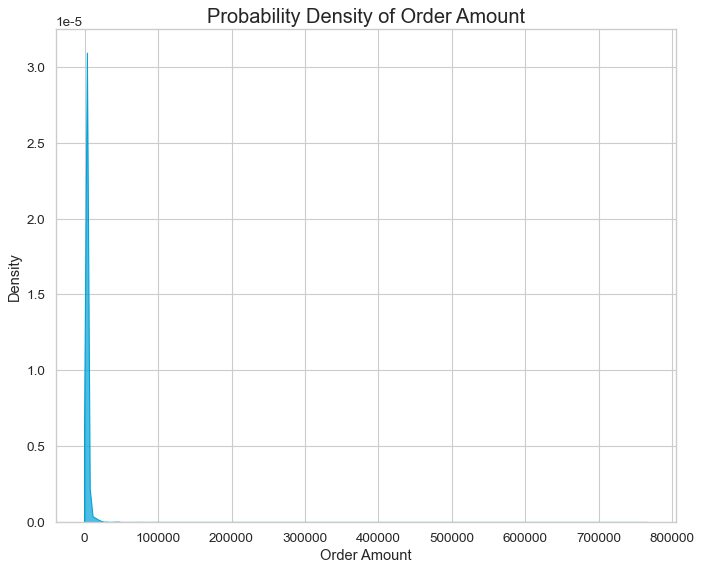

In [66]:
plt.figure(figsize=(10, 8), dpi=80)
sns.kdeplot(
    data["Order Amount"],
    fill=True,
    color="#01a2d9",
    label="Order Amount",
    alpha=0.7,
)
plt.title("Probability Density of Order Amount", fontsize=18)
plt.xlabel("Order Amount")
plt.ylabel("Density")
plt.show()

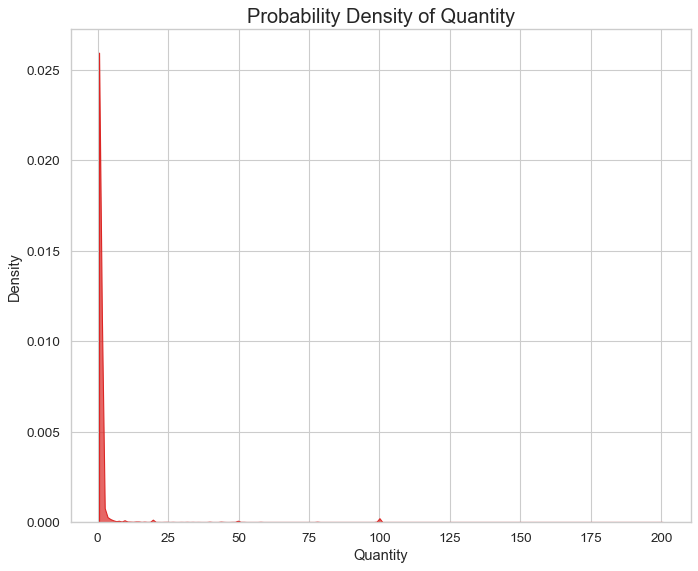

In [67]:
plt.figure(figsize=(10, 8), dpi=80)
sns.kdeplot(
    data["Quantity"],
    fill=True,
    color="#dc2624",
    label="Quantity",
    alpha=0.7,
)
plt.title("Probability Density of Quantity", fontsize=18)
plt.xlabel("Quantity")
plt.ylabel("Density")
plt.show()

**Interpretation:** Both distributions are **strongly right-skewed**. Most transactions involve low amounts and small quantities, while a small number have very high amounts or quantities. This pattern is common in e-commerce data.

### 4.3 Detect Outliers with the Boxplot Rule

- Apply the standard IQR rule: **a value is an outlier if it falls outside `[Q1 - 1.5 × IQR, Q3 + 1.5 × IQR]`.**
- Apply the rule to Order Amount and Quantity, combine the flagged row indices, and deduplicate them to obtain the set of feature-outlier records.

In [68]:
# Detect IQR-based outliers and store the corresponding row indices.
num_samples = data.shape[0]
data_without_outliers = data.copy()
outlier_indices = []

for column in ["Order Amount", "Quantity"]:
    feature = data[column]
    q1 = np.quantile(feature, 0.25)
    q3 = np.quantile(feature, 0.75)
    iqr = q3 - q1
    outliers = feature[(feature < q1 - 1.5 * iqr) | (feature > q3 + 1.5 * iqr)]
    outlier_indices.extend(outliers.index)

In [69]:
len(outlier_indices)

31266

In [70]:
outlier_indices = set(outlier_indices)  # Deduplicate row indices.

In [71]:
len(outlier_indices)  # Most records are outliers in only one quantitative feature.

29949

**Interpretation:** There are 31,266 flagged indices before deduplication and **29,949** afterward. The small overlap indicates that most records are outliers in only one of the two features.

In [72]:
len(outlier_indices) / data.shape[0]  # Too large a share to remove indiscriminately.

0.22812723754970216

**Interpretation:** Feature outliers account for **22.8%** of all records—too large a share to remove indiscriminately.

In [73]:
# How many feature-outlier records are labeled as abnormal transactions?
(data.loc[list(outlier_indices), "Abnormal Label"] == 1).sum()

np.int64(7368)

**Interpretation:** Of the feature-outlier records, **7,368** are labeled as abnormal transactions—more than one-quarter of all abnormal records. They must not be removed without further evidence.

### 4.4 Association Between Feature Outliers and Transaction Abnormality

Create a binary Feature Outlier indicator and calculate its Pearson correlation with the target.

In [74]:
df = pd.DataFrame(index=data.index)

In [75]:
df["Feature Outlier"] = 0

In [76]:
df.loc[list(outlier_indices), "Feature Outlier"] = 1

In [77]:
pd.concat([df["Feature Outlier"], data["Abnormal Label"]], axis=1).corr()

,Feature Outlier,Abnormal Label
Feature Outlier,1.000000,0.040428
Abnormal Label,0.040428,1.000000


**Interpretation:** The correlation is only **0.040**, close to zero. Feature outlier status therefore has almost no linear association with transaction abnormality.

### 4.5 Outlier-Treatment Decision

The analysis shows that:

1. Feature outliers are too common (22.8%) to delete wholesale.
2. Feature outlier status has no meaningful association with the target.
3. Large-value and bulk orders can be legitimate e-commerce activity.

**Decision:** Retain the original values for now and revisit outlier treatment only if model diagnostics provide a reason to do so.

---

## 5. Part 1 Summary and Data Export

### Key Findings

1. **Inferred source:** Category and channel evidence suggests that the data is a sample of **GOME's 2013 online transactions**.
2. **Data granularity:** Each row represents a transaction or product line within an order, not an entire order.
3. **Target behavior:** Approximately 21% of records are abnormal, so imbalance is mild; labels are almost perfectly consistent within each Order ID.
4. **Missing values:** Missingness is below 1.1% and unrelated to abnormality, so incomplete rows were removed.
5. **Artificial data:** Order Date shows evidence of artificial construction and was removed.
6. **Numerical outliers:** Approximately 22.8% of records contain an IQR-based feature outlier, but outlier status is almost unrelated to the target, so these records were retained.

### Data Export

Save the cleaned English-schema dataset as a separate CSV file for later modeling. A separate filename prevents this translated workflow from overwriting the original project's processed dataset.

In [78]:
data.head()

,Order ID,Order Time,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,User ID,City,Abnormal Label
0,4283851335,14:09:49,手机摄影数码,POP,8002042497,三星,766000.0,200,主站,合并支付,dakehu_zy,上海市,1
1,4276537082,14:16:47,电视冰箱洗衣机空调,POP,8001992420,樱花,19900.0,100,主站,合并支付,qq-3be293b,泉州市,1
2,4281111595,10:44:46,家具建材,POP,8002199518,纬度空间,100.0,100,主站,合并支付,nonscorpio,广州市,1
3,3977175284,23:26:19,手机摄影数码,POP,8002237611,伊斯贝,990.0,100,主站,合并支付,swt6263122,宁德市,0
4,4106833871,16:47:34,家居日用,POP,8002212182,品道天元,8800.0,100,主站,合并支付,qq-edf69d7,深圳市,0


In [79]:
data.to_csv("data/abnormal_order2_en.csv", index=False)

**Part 1—business-context analysis and data exploration—is now complete.** The processed dataset contains approximately 131,282 records and 13 fields after removing Order Date. It has no missing values and excludes the identified artificial duplicates. Part 2 will cover feature engineering and model development.